# Polynomial Regression

Polynomial regression is a extention of linear regression that allows modelling nonlinear relationships by including powers for input variables
 y = m0+ m1x1+ ....+mnxn+e
 y=  target 
 m0 = coeffient 
 x = input
 e =  error term

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [3]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error
from sklearn.tree import DecisionTreeRegressor

y  =  x^3 + 100

In [4]:
n_samples = 100
x = np.linspace(0,10,100)
rng =  np.random.randn(n_samples)*100
y =  x** 3 + rng + 100

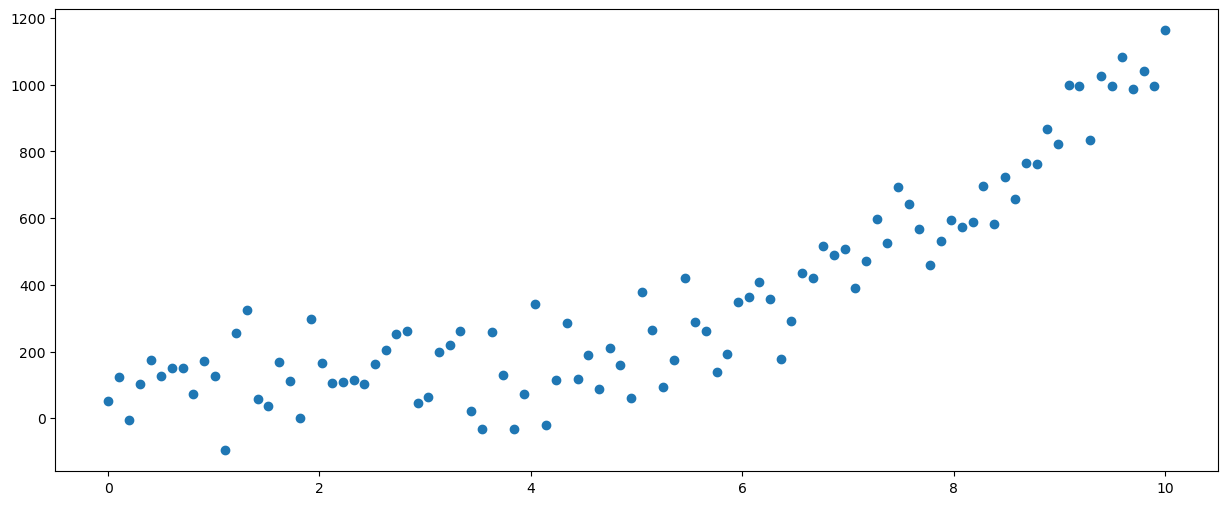

In [5]:
plt.figure(figsize=(15,6))
plt.scatter(x,y )

# Linear model

R2 0.7349217266380241


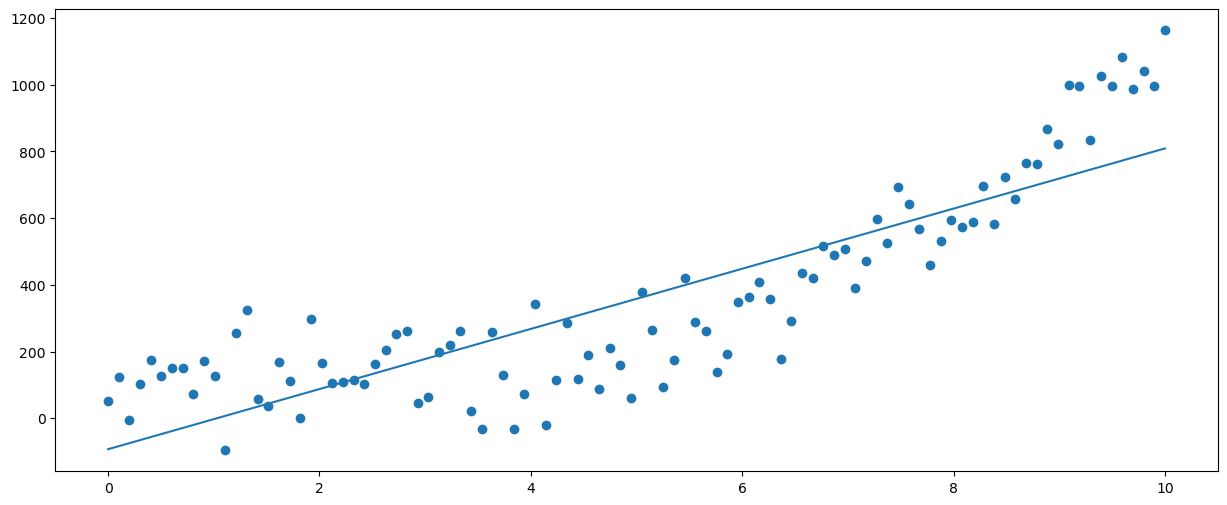

In [6]:

model  = LinearRegression()
model.fit(x.reshape(-1 ,1), y)
y_lnr_prd = model.predict(x.reshape(-1,1))
plt.figure(figsize= (15,6))
plt.scatter (x, y)
plt.plot(x, y_lnr_prd)
print("R2", r2_score(y, y_lnr_prd))

# Polynomial 

In [7]:
poly = PolynomialFeatures(degree= 2)

In [8]:
x_poly  = poly.fit_transform(x.reshape(-1,1))

In [9]:
mod = LinearRegression()
mod.fit(x_poly, y.reshape(-1,1))
y_prd  = mod.predict(x_poly
                     )
print(r2_score(y, y_prd))

0.9021601759975693


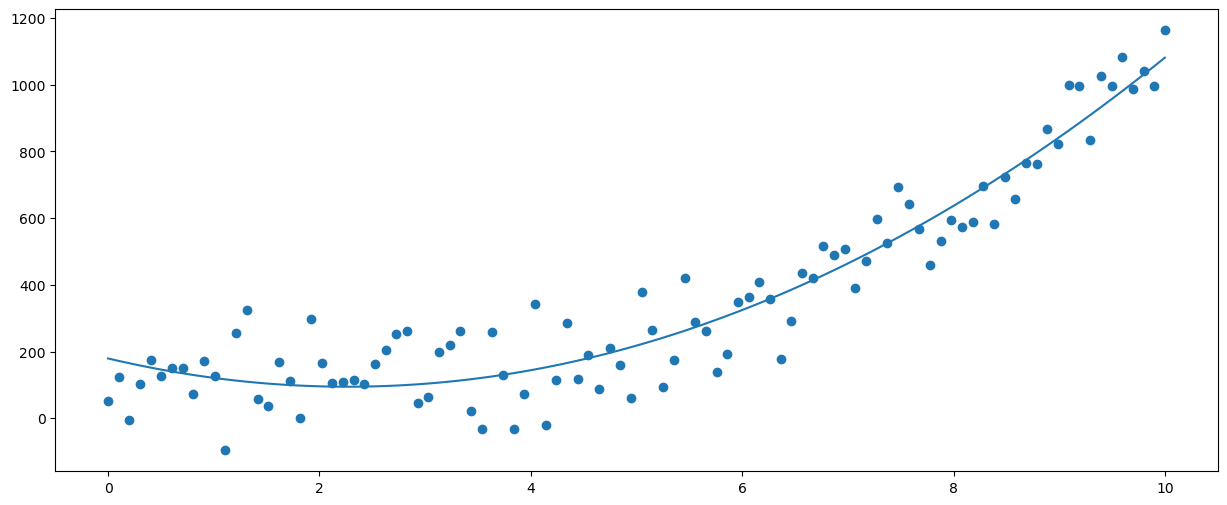

In [10]:
plt.figure(figsize= (15,6))
plt.scatter (x, y)
plt.plot(x, y_prd)


# Non linear relationships ----- Decision Tree

In [39]:
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor

In [12]:
data  = fetch_california_housing(as_frame= True)
df = data.frame

In [13]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [14]:
df1  = df.iloc[: , :-1]

In [15]:
y = data.target

In [16]:
y

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: MedHouseVal, Length: 20640, dtype: float64

In [17]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')

In [18]:
x = df[['MedInc']].values

In [34]:
tree  = DecisionTreeRegressor(max_depth= 3)

In [35]:
tree.fit(x, y)

DecisionTreeRegressor(max_depth=3)

In [36]:
sort_indx = x.flatten().argsort()

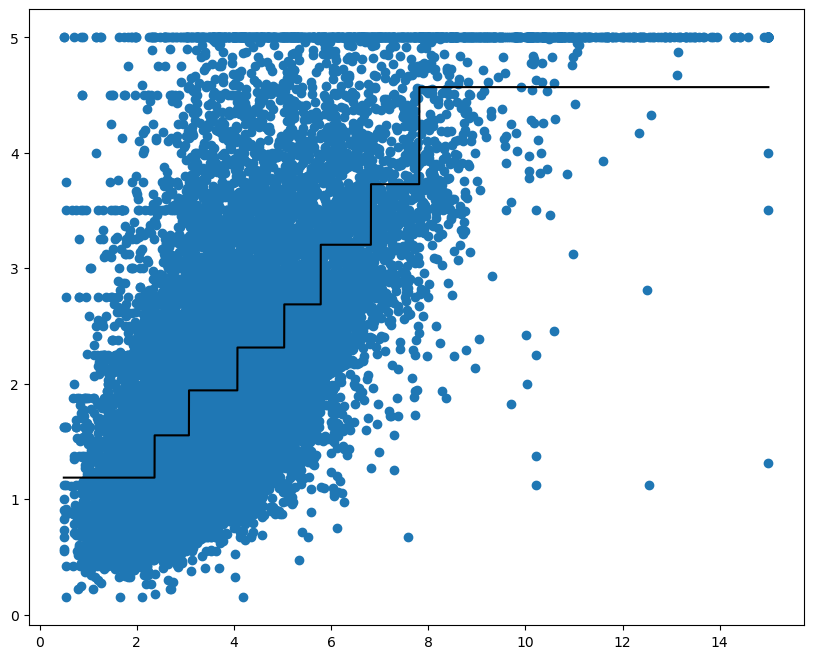

In [37]:
plt.figure(figsize= (10,8))
plt.scatter(x[sort_indx], y[sort_indx] )
plt.plot(x[sort_indx], tree.predict(x[sort_indx] ), c ='k')

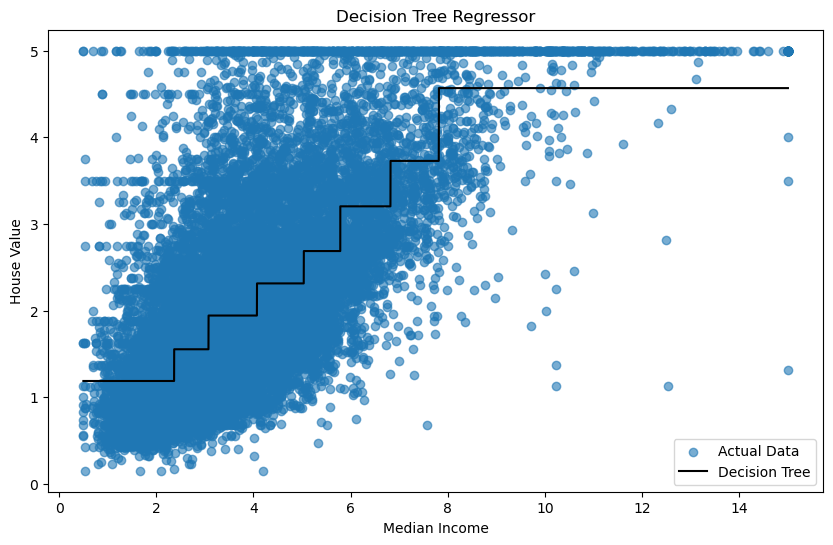

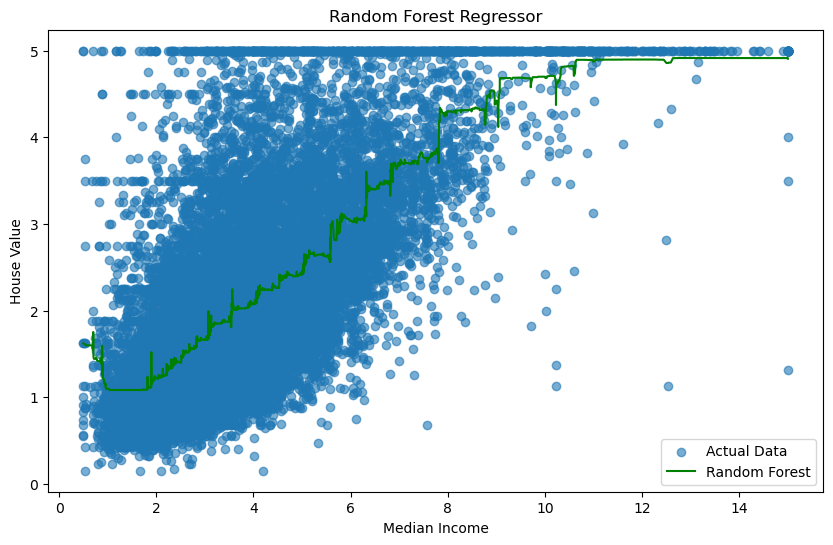

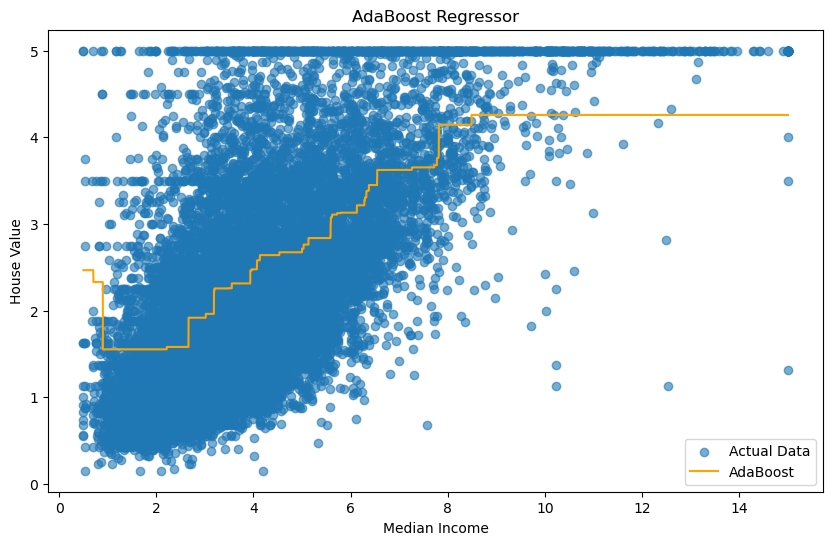

R2 Score - Decision Tree:    0.48240295133703315
R2 Score - Random Forest:    0.49724394575279585
R2 Score - AdaBoost:         0.41764000699258197


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.metrics import r2_score

# Load California Housing data
data = fetch_california_housing(as_frame=True)
df = data.frame
X = df[['MedInc']].values  # Feature
y = data.target            # Target

# Sort values for smooth plotting
sorted_idx = X.flatten().argsort()
X_sorted = X[sorted_idx]
y_sorted = y.values[sorted_idx]

# --- 1. Decision Tree Regressor ---
tree = DecisionTreeRegressor(max_depth=3)
tree.fit(X, y)
y_tree_pred = tree.predict(X_sorted)

plt.figure(figsize=(10, 6))
plt.scatter(X_sorted, y_sorted, label='Actual Data', alpha=0.6)
plt.plot(X_sorted, y_tree_pred, label='Decision Tree', color='black')
plt.title('Decision Tree Regressor')
plt.xlabel('Median Income')
plt.ylabel('House Value')
plt.legend()
plt.show()

# --- 2. Random Forest Regressor ---
forest = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
forest.fit(X, y)
y_forest_pred = forest.predict(X_sorted)

plt.figure(figsize=(10, 6))
plt.scatter(X_sorted, y_sorted, label='Actual Data', alpha=0.6)
plt.plot(X_sorted, y_forest_pred, label='Random Forest', color='green')
plt.title('Random Forest Regressor')
plt.xlabel('Median Income')
plt.ylabel('House Value')
plt.legend()
plt.show()

# --- 3. AdaBoost Regressor ---
ada = AdaBoostRegressor(DecisionTreeRegressor(max_depth=3), n_estimators=100, learning_rate=0.5, random_state=42)
ada.fit(X, y)
y_ada_pred = ada.predict(X_sorted)

plt.figure(figsize=(10, 6))
plt.scatter(X_sorted, y_sorted, label='Actual Data', alpha=0.6)
plt.plot(X_sorted, y_ada_pred, label='AdaBoost', color='orange')
plt.title('AdaBoost Regressor')
plt.xlabel('Median Income')
plt.ylabel('House Value')
plt.legend()
plt.show()

# --- R2 Scores ---
print("R2 Score - Decision Tree:   ", r2_score(y, tree.predict(X)))
print("R2 Score - Random Forest:   ", r2_score(y, forest.predict(X)))
print("R2 Score - AdaBoost:        ", r2_score(y, ada.predict(X)))


# According to adaboost

In [47]:
x = df1
ada =AdaBoostRegressor()
ada.fit(x, y)

AdaBoostRegressor()

In [48]:
ada.feature_importances_

array([0.32427163, 0.03665706, 0.07939533, 0.01643095, 0.05058244,
       0.11155971, 0.18646625, 0.19463662])

In [49]:
df1.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='object')

In [54]:
result = pd.DataFrame({
    'Feature': df1.columns,
    'Importance': ada.feature_importances_
})


In [55]:
result

,Feature,Importance
0,MedInc,0.324272
1,HouseAge,0.036657
2,AveRooms,0.079395
3,AveBedrms,0.016431
4,Population,0.050582
5,AveOccup,0.111560
6,Latitude,0.186466
7,Longitude,0.194637


In [59]:
result_columns = ['Feature']

In [62]:
result.sort_values(by='Feature')

,Feature,Importance
3,AveBedrms,0.016431
5,AveOccup,0.111560
2,AveRooms,0.079395
1,HouseAge,0.036657
6,Latitude,0.186466
7,Longitude,0.194637
0,MedInc,0.324272
4,Population,0.050582
